In [1]:
# !uv pip install wandb tensorboard

In [2]:
import tensorboard

In [3]:
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

In [5]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

batch_size = 4
trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2
)


classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

/Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


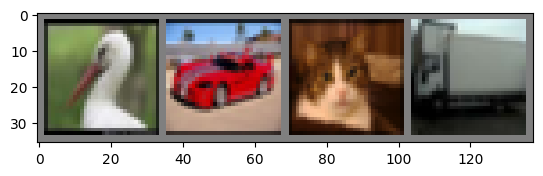

bird  car   cat   truck


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [7]:
from typing import Any
import torch.nn as nn
import torch.nn.functional as F


class CifarNet(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.conv1 = nn.Conv2d(3,6,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimension except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x
    
    
net = CifarNet()
        

In [8]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)


In [9]:
epochs = 5
global_step = 0

# Setup a learning rate scheduler (e.g., StepLR or MultiStepLR, or keep fixed if not desired)
from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

for epoch in range(epochs):
    running_loss = 0.0
    net.train()
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)

        global_step += 1
        loss.backward()

        # Log gradient norms for each layer
        for name, param in net.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()
                writer.add_scalar(f"GradNorm/{name}", grad_norm, global_step)

        optimizer.step()

        # print statistics
        running_loss += loss.item()
        writer.add_scalar("Loss/Train", loss.item(), global_step)
        writer.add_scalar("LR", optimizer.param_groups[0]['lr'], global_step)

        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    # Test loss logging after each epoch
    net.eval()
    test_loss = 0.0
    test_steps = 0
    with torch.no_grad():
        for test_inputs, test_labels in testloader:
            test_outputs = net(test_inputs)
            t_loss = criterion(test_outputs, test_labels)
            test_loss += t_loss.item()
            test_steps += 1
    avg_test_loss = test_loss / test_steps if test_steps > 0 else 0.0
    writer.add_scalar("Loss/Test", avg_test_loss, epoch)
    print(f"Epoch {epoch+1}: Test loss: {avg_test_loss:.3f}")

    # Step the scheduler at end of epoch
    scheduler.step()

print('Finished Training')


[1,  2000] loss: 2.106
[1,  4000] loss: 2.007
[1,  6000] loss: 1.945
[1,  8000] loss: 1.943
[1, 10000] loss: 1.939
[1, 12000] loss: 1.942
Epoch 1: Test loss: 2.088
[2,  2000] loss: 1.886
[2,  4000] loss: 1.868
[2,  6000] loss: 1.868
[2,  8000] loss: 1.858
[2, 10000] loss: 1.823
[2, 12000] loss: 1.817
Epoch 2: Test loss: 1.856
[3,  2000] loss: 1.751
[3,  4000] loss: 1.745
[3,  6000] loss: 1.737
[3,  8000] loss: 1.692
[3, 10000] loss: 1.705
[3, 12000] loss: 1.699
Epoch 3: Test loss: 1.678
[4,  2000] loss: 1.599
[4,  4000] loss: 1.583
[4,  6000] loss: 1.548
[4,  8000] loss: 1.574
[4, 10000] loss: 1.561
[4, 12000] loss: 1.572
Epoch 4: Test loss: 1.584
[5,  2000] loss: 1.447
[5,  4000] loss: 1.458
[5,  6000] loss: 1.434
[5,  8000] loss: 1.435
[5, 10000] loss: 1.435
[5, 12000] loss: 1.451
Epoch 5: Test loss: 1.493
Finished Training
